<div style="background-color:#111827;
padding:25px;
border-left:8px solid #F59E0B;
border-radius:10px;
margin-bottom:20px;">

<h1 style="color:white;
font-size:34px;
margin:0;">
Detección de Fraude con ML: Del Modelo a la Decisión de Negocio
</h1>

<p style="color:#D1D5DB;
font-size:16px;
margin-top:10px;">
Comparativa entre Regresión Logística y XGBoost con matriz de impacto económico en contexto argentino.
</p>

</div>

En el sector financiero, detectar una transacción fraudulenta a tiempo puede significar la diferencia entre recuperar o perder miles de pesos. Pero no todos los errores cuestan lo mismo: dejar pasar un fraude es mucho más costoso que bloquear por error una compra legítima.
Este notebook aborda ese problema desde dos ángulos: el técnico y el de negocio. Se entrena y compara una Regresión Logística usada como benchmarkc contra un modelo XGBoost sobre un dataset de transacciones con tarjeta de crédito, evaluando no solo métricas estándar sino también el impacto económico real de cada tipo de error en el contexto argentino.

**Flujo del análisis:**
1. Limpieza y preparación de datos
2. Análisis exploratorio y correlaciones
3. Entrenamiento y comparativa de modelos
4. Ajuste de umbral de decisión
5. Matriz de impacto económico
6. Explicabilidad con SHAP
7. Análisis de errores (falsos negativos)

**El dataset** contiene registros de transacciones con variables como monto, saldo, distancia al comercio, hora de operación, antecedentes de fraude e indicador de operación internacional. Incluye ruido real: valores corruptos, nulos con distintos criterios de imputación etc.

<h2 style="
background-color:#111827;
color:white;
padding:14px;
border-radius:10px;
border-left:6px solid #F59E0B;
font-size:28px;
">
Índice
</h2>

<div style="
background-color:#1F2937;
padding:20px;
border-radius:10px;
margin-top:10px;
color:#E5E7EB;
font-size:16px;
line-height:2;
">

<a href="#0" style="color:#D1D5DB; text-decoration:none;">
1. Preparación y limpieza de los datos
</a>
<br>

<a href="#1" style="color:#D1D5DB; text-decoration:none;">
2. Análisis exploratorio de datos (EDA)
</a>
<br>

<a href="#2" style="color:#D1D5DB; text-decoration:none;">
3. Modelado y evaluación
</a>
<br>

<a href="#4" style="color:#D1D5DB; text-decoration:none;">
4. Conclusiones
</a>

</div>

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">01</span>
Preparación y limpieza de los datos
</div>
<a id="0"></a>

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # Borrar warnings

In [2]:
df = pd.read_csv("Fraude_Credito.csv")
df.head(3)

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0


In [3]:
df.columns = ["Edad", "Monto", "Saldo", "Trans.x.dia", "Internacional", "Hora", "Antecedente_fraude", "Distancia_comercio", "Riesgo_comercio", "Es_fraude"]



In [4]:
df.sample(5)

,Edad,Monto,Saldo,Trans.x.dia,Internacional,Hora,Antecedente_fraude,Distancia_comercio,Riesgo_comercio,Es_fraude
6244,71.0,10892.15,23133.11,12.0,0.0,8.0,0.0,1501.5,2.5,1
19772,32.0,1214.30,29208.76,NaN,0.0,13.0,0.0,1826.3,2.7,0
7359,32.0,6842.41,8439.56,24.0,0.0,NaN,0.0,1374.4,2.2,0
14445,24.0,9163.88,40464.25,17.0,0.0,22.0,1.0,3658.1,8.6,1
3612,52.0,10371.15,3292.27,30.0,0.0,11.0,0.0,1114.4,1.1,0


In [5]:
df.describe()

,Monto,Saldo,Trans.x.dia,Internacional,Hora,Antecedente_fraude,Distancia_comercio,Riesgo_comercio,Es_fraude
count,31653.000000,31655.000000,31654.000000,31649.000000,31657.000000,31654.000000,31657.000000,31656.000000,32300.000000
mean,7471.580234,25020.772509,24.924591,0.145818,11.466532,0.081032,2500.266033,5.512513,0.481734
std,4324.127410,14423.748726,14.150679,0.352929,6.920080,0.272889,1444.739723,2.594919,0.499674
min,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,3723.400000,12510.295000,13.000000,0.000000,5.000000,0.000000,1250.000000,3.300000,0.000000
50%,7475.070000,25050.490000,25.000000,0.000000,11.000000,0.000000,2507.000000,5.500000,0.000000
75%,11199.090000,37530.215000,37.000000,0.000000,17.000000,0.000000,3741.300000,7.800000,1.000000
max,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,15.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                31656 non-null  object 
 1   Monto               31653 non-null  float64
 2   Saldo               31655 non-null  float64
 3   Trans.x.dia         31654 non-null  float64
 4   Internacional       31649 non-null  float64
 5   Hora                31657 non-null  float64
 6   Antecedente_fraude  31654 non-null  float64
 7   Distancia_comercio  31657 non-null  float64
 8   Riesgo_comercio     31656 non-null  float64
 9   Es_fraude           32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB


In [7]:
df.isnull().sum()

Edad                  644
Monto                 647
Saldo                 645
Trans.x.dia           646
Internacional         651
Hora                  643
Antecedente_fraude    646
Distancia_comercio    643
Riesgo_comercio       644
Es_fraude               0
dtype: int64

In [8]:
df["Edad"].value_counts().head(5)

50.0    608
62.0    592
51.0    590
72.0    585
34.0    583
Name: Edad, dtype: int64

In [9]:
# Borrar palabras "_err" o "err" reemplazándolo por ningun valor, para limpiar la columna.
df['Edad'] = df['Edad'].astype(str).str.replace(r'_?err', '', regex=True)

In [10]:
df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce') # Convertir la columna a numerico.

In [11]:
df['Edad'] = df['Edad'].fillna(df['Edad'].mean()) # Reemplazo los nulos por media.

In [12]:
df['Monto'] = df['Monto'].fillna(df['Monto'].median())

In [13]:
df['Saldo'] = df['Saldo'].fillna(df['Saldo'].median())

In [14]:
df["Trans.x.dia"].value_counts().sample(5)

38.0    632
1.0     671
29.0    622
45.0    658
22.0    669
Name: Trans.x.dia, dtype: int64

In [15]:
df['Trans.x.dia'] = df['Trans.x.dia'].fillna(0) # Mas conservador rellenar con 0.

In [16]:
df["Internacional"].value_counts()

0.0    27034
1.0     4615
Name: Internacional, dtype: int64

In [17]:
df['Internacional'] = df['Internacional'].fillna(2) # Por el echo de que no se sepa el origen puede ser un patron a tener en cuenta por eso agrego el valor 2.

In [18]:
df["Hora"].value_counts().tail(5)

18.0    1281
5.0     1277
23.0    1272
6.0     1268
28.0       1
Name: Hora, dtype: int64

In [19]:
# Cambia cualquier valor 28 que seria un valor de hora ilogico por 23 en la columna Hora.
df.loc[df['Hora'] == 28, 'Hora'] = 23

In [20]:
df['Hora'] = df['Hora'].fillna(df['Hora'].mode()[0]) # Llenar los faltantes con la moda.

In [21]:
print (df.Es_fraude.value_counts())
print("Se evidencia ....")

0    16740
1    15560
Name: Es_fraude, dtype: int64
Se evidencia ....


In [22]:
df["Antecedente_fraude"].value_counts()

0.0    29089
1.0     2565
Name: Antecedente_fraude, dtype: int64

In [23]:
# 0 = No tiene, 1 = Tiene, 2 = Sin información
df['Antecedente_fraude'] = df['Antecedente_fraude'].fillna(2)

In [24]:
df['Distancia_comercio'].value_counts()

4240.4    6
1441.2    6
1620.3    6
2358.3    6
4746.9    5
         ..
4999.3    1
4631.9    1
4082.4    1
1904.1    1
932.2     1
Name: Distancia_comercio, Length: 23265, dtype: int64

In [25]:
df['Distancia_comercio'] = df['Distancia_comercio'].fillna(df['Distancia_comercio'].median())

In [26]:
df['Riesgo_comercio'] = df['Riesgo_comercio'].fillna(df['Riesgo_comercio'].median())

In [27]:
df.isnull().sum() # Aqui deberian salir todos los valores en 0 porque se trataron todos los valores nulos.

Edad                  0
Monto                 0
Saldo                 0
Trans.x.dia           0
Internacional         0
Hora                  0
Antecedente_fraude    0
Distancia_comercio    0
Riesgo_comercio       0
Es_fraude             0
dtype: int64

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">02</span>
Análisis exploratorio de datos (EDA)
</div>
<a id="1"></a>

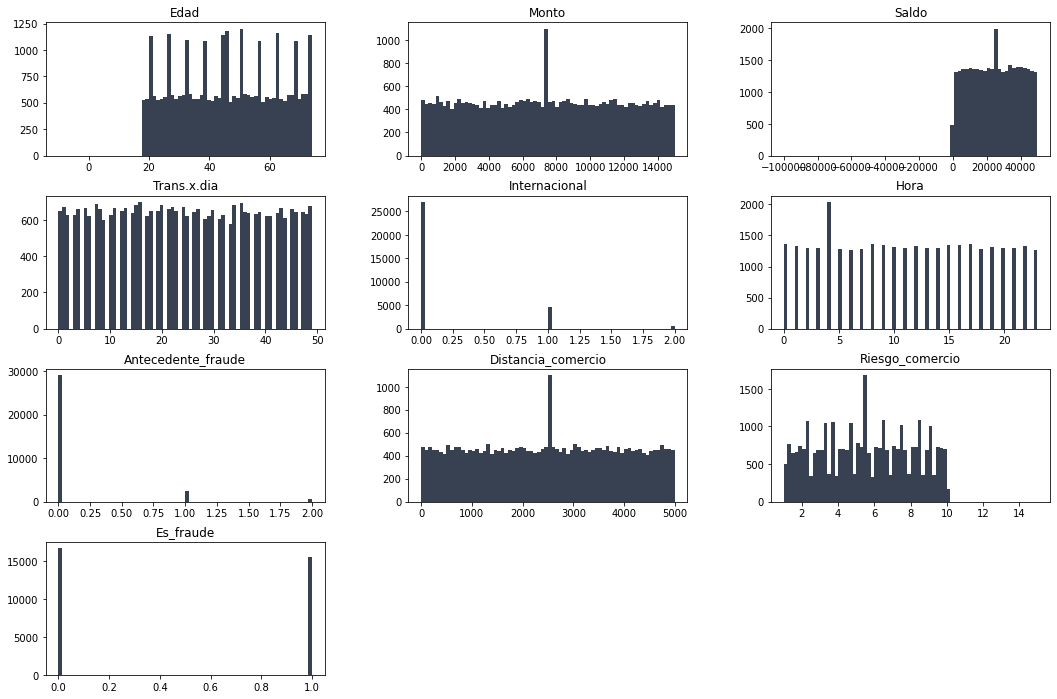

In [28]:
_ = df.hist(figsize=(18, 12), bins=70, color='#374151', grid=False)

# _ = para evitar imprimir el array

In [29]:
df.columns

Index(['Edad', 'Monto', 'Saldo', 'Trans.x.dia', 'Internacional', 'Hora',
       'Antecedente_fraude', 'Distancia_comercio', 'Riesgo_comercio',
       'Es_fraude'],
      dtype='object')

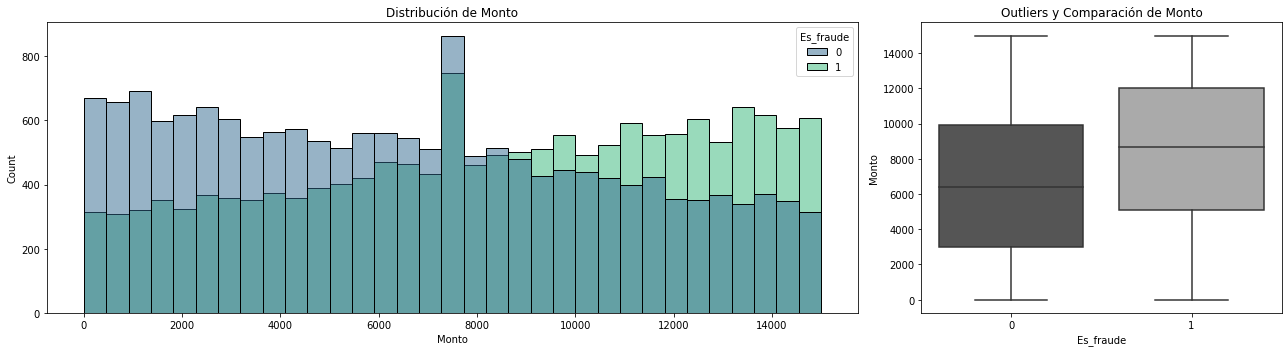

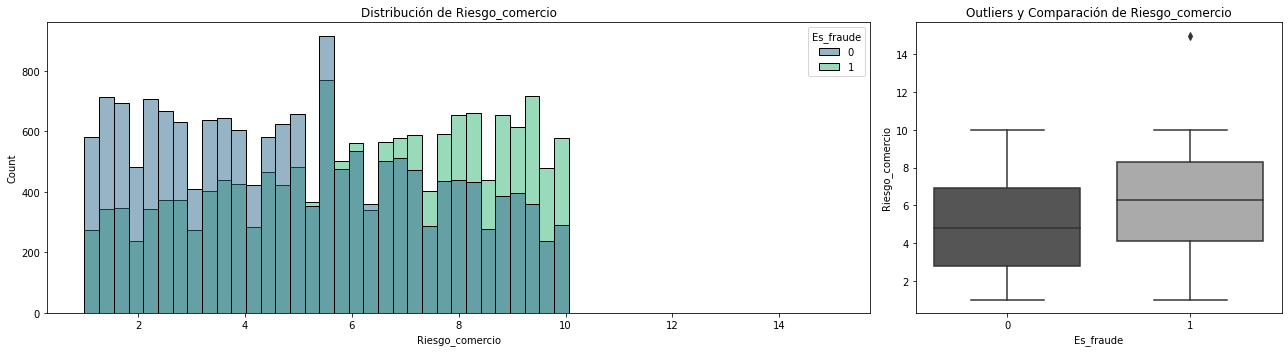

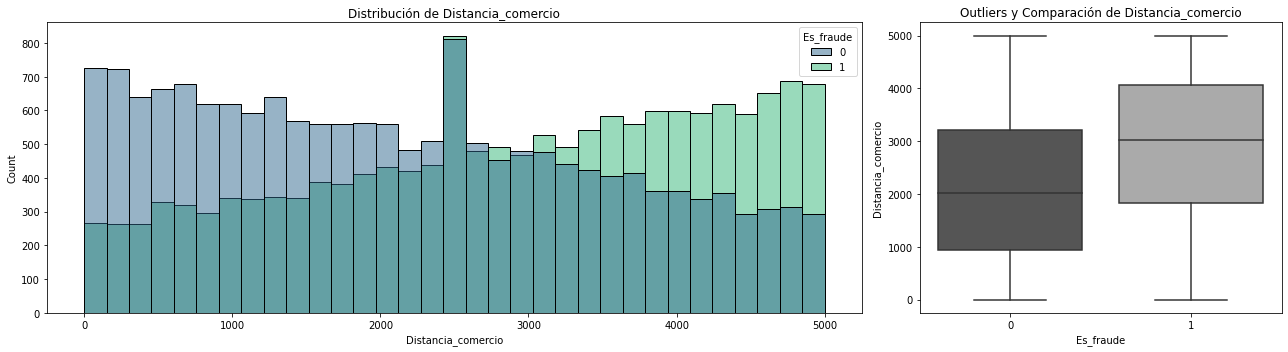

In [30]:
def plot_variable_analisis(df, col):
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [0.9, 0.4]})
    
    # Histograma para ver la forma de los datos
    sns.histplot(data=df, x=col, hue='Es_fraude', kde=False, ax=ax_hist, palette='viridis')
    ax_hist.set_title(f'Distribución de {col}')
    
    # Boxplot para ver los outliers y la diferencia
    sns.boxplot(data=df, x='Es_fraude', y=col, ax=ax_box, palette='gist_gray')
    ax_box.set_title(f'Outliers y Comparación de {col}')
    
    plt.tight_layout()
    plt.show()

# Graficos a mostrar...
plot_variable_analisis(df, 'Monto')
plot_variable_analisis(df, 'Riesgo_comercio')
plot_variable_analisis(df, 'Distancia_comercio')

Lo gris es "no fraude", lo verde claro es fraude y lo que coincide o se solapa entre los dos es verde oscuro. 

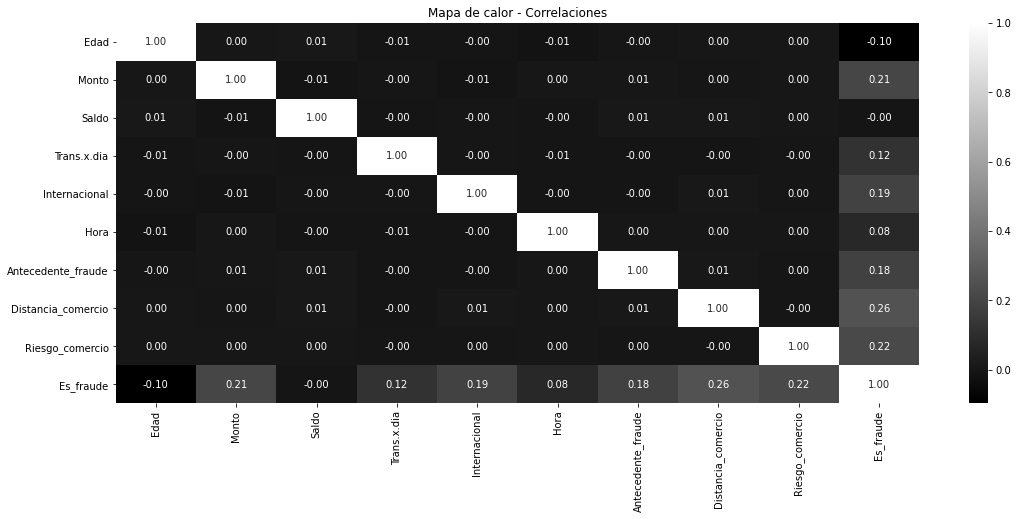

In [31]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(18, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='gist_gray')
plt.title('Mapa de calor - Correlaciones')
plt.show()

Hay independencia casi total de las variables entre sí excepto con la variable objetivo. Casi todas las variables independientes (Monto, Saldo, 
Hora, etc.) tienen una correlación cercana a 0.00 entre ellas, osea no hay multicolinealidad. Cada variable aporta información única y no repite
lo que otra ya dice.

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">03</span>
Modelado y evaluación
</div>
<a id="2"></a>

## ❑ Regresión Logística

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [33]:
# Cargamos los datos y los dividimos en conjuntos para entrenar y testear.
data = df
y = data["Es_fraude"] # Aca le pido que Y sea mi objetivo a predecir
X = data.drop(["Es_fraude"], axis=1) # Aplico que X sean todas las columnas menos la del objetivo.
(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.30,
                                     random_state=42,
                                     stratify=y) # Las proporciones se mantienen en ambos conjuntos. Tanto train como test tendrian similares cantidades de ambas clases.

Como la regresión es muy sensible a la escala de los datos. Y este dataset hay variables como Monto (que puede ser valores en miles) y Hora (0 a 23)
se debe aplicar un escalado de la informacion (StandardScaler). Puesto que si no lo hago, el modelo le dará más importancia a las variables con números
más grandes solo porque son grandes no porque sean más importantes

In [34]:
# Escaladar las variables.
scaler = StandardScaler()

In [35]:
X_train_scaled = scaler.fit_transform(X_train) # El fit se hace SOLO en el train para aprender la media y desviación.
X_test_scaled = scaler.transform(X_test) # El transform se hace en el test usando lo aprendido del train

In [36]:
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42) #Entrenar el modelo con los datos ESCALADOS
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [37]:
y_pred = lr.predict(X_test_scaled) # Predecir.

In [38]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

threshold = 0.3 # Detectara más fraudes pero es preferible llamar a un cliente para verificar una compra legítima que dejar pasar un robo de miles de pesos
y_pred = (y_prob >= threshold).astype(int)

In [39]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
print("--- Métricas de Desempeño ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")
print()
print("---Matriz de confusión:---\n", confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

--- Métricas de Desempeño ---
Accuracy: 0.6679
Recall:   0.9122
AUC-ROC:  0.7987

---Matriz de confusión:---
 [[2214 2808]
 [ 410 4258]]


El modelo de Regresión Logística, optimizado mediante un umbral de decisión de 0.3 y un balanceo de clases, se comporta como un sistema de seguridad de alta sensibilidad que prioriza la detección de amenazas. Con un Recall del 91.22%, el algoritmo logra identificar eficazmente 91 de cada 100 fraudes reales, logrando capturar un total de 4,258 casos críticos. Sin embargo, esta postura defensiva conlleva un costo operativo significativo en la experiencia del cliente: al ser un umbral tan bajo, el modelo genera 2,808 falsos positivos, lo que se traduce en casi 3,000 transacciones legítimas bloqueadas o enviadas a revisión manual innecesariamente. Finalmente, el riesgo residual se concentra en 410 fraudes que lograron evadir el control al ser clasificados como legales, lo que representa el margen de pérdida financiera que el sistema, bajo su configuración actual, aún no consigue mitigar.

## ❑ XGBoost

XGBoost no usa datos escalados,  usa X_train / X_test sin escalar. 


In [40]:
ratio = (y_train == 0).sum() / (y_train == 1).sum() 
# Cálculo rápido del ratio para el balanceo, se le pide a XGBoost que le preste mucha mas atención a la clase minoritaria (el fraude).

In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,  # balanceo las clases
    eval_metric="auc"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [42]:
# 2. Predecir probabilidades
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 3. Aplicar el mismo umbral para comparar peras con peras
threshold = 0.3
y_pred_final = (y_prob_xgb >= threshold).astype(int)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score

print(f"--- RESULTADOS XGBOOST (Umbral {threshold}) ---")
print("AUC-ROC:", roc_auc_score(y_test, y_prob_xgb))
print("Recall: ", recall_score(y_test, y_pred_final))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_final))

--- RESULTADOS XGBOOST (Umbral 0.3) ---
AUC-ROC: 0.8199447282002036
Recall:  0.8918166238217652

Matriz de confusión:
 [[2493 2529]
 [ 505 4163]]


**Regresión Logistica (Benchmark)**

**[[ 2214  2808 ]**   <-- Transacciones Legales (2214 **OK**, 2808 Bloqueos erróneos)  
**[  410  4258 ]]**  <-- Transacciones de Fraude (410 Escapados, 4258 **Frenados**)

**XGBoost**
 
**[[ 2493  2529 ]**   <-- Transacciones Legales (2493 **OK**, 2529 Bloqueos erróneos)  
**[  505  4163 ]]**  <-- Transacciones de Fraude (505 Escapados, 4163 **Frenados**)

La Regresión Logística es más robusta en seguridad (Recall 91.22% vs 89.18%), capturando 95 fraudes más que el XGBoost. Sin embargo, el XGBoost es más 'inteligente' con los clientes honestos, generando menos bloqueos erróneos y reduciendo costos operativos de soporte.
Lo siguiente es proceder a realizar un ajuste fino del umbral de decisión (bajarlo a 0.2, hacerlo mas "paranoico", buscando igualar o superar la capacidad de detección de la logística.

In [44]:
threshold_agresivo = 0.20 # Umbral mas bajo. 
y_pred_xgb_020 = (y_prob_xgb >= threshold_agresivo).astype(int)

from sklearn.metrics import confusion_matrix, recall_score

print(f"--- XGBOOST con Umbral {threshold_agresivo} ---")
print("Recall: ", recall_score(y_test, y_pred_xgb_020))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_xgb_020))

--- XGBOOST con Umbral 0.2 ---
Recall:  0.9537275064267352

Matriz de confusión:
 [[1686 3336]
 [ 216 4452]]


**Regresión Logistica (Benchmark)**

**[[ 2214  2808 ]**   <-- Transacciones Legales (2214 **OK**, 2808 Bloqueos erróneos)  
**[  410  4258 ]]**  <-- Transacciones de Fraude (410 Escapados, 4258 **Frenados**)

**XGBoost (Umbral 0,3)**
 
**[[ 2493  2529 ]**   <-- Transacciones Legales (2493 **OK**, 2529 Bloqueos erróneos)  
**[  505  4163 ]]**  <-- Transacciones de Fraude (505 Escapados, 4163 **Frenados**)

**XGBoost (Umbral 0,2)**
 
**[[ 1686  3336 ]**   <-- Transacciones Legales (1686 **OK**, 3336 Bloqueos erróneos)  
**[  216  4452 ]]**  <-- Transacciones de Fraude (216 Escapados, 4452 **Frenados**)

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">04</span>
Conclusiones
</div>
<a id="3"></a>

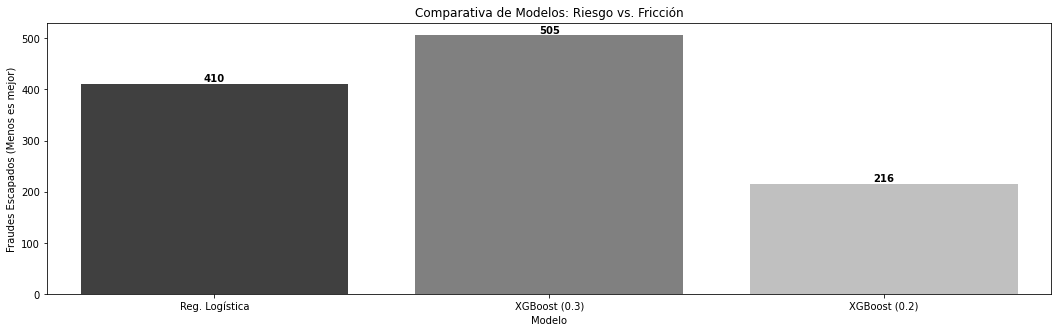

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Los datos
data = {
    'Modelo': ['Reg. Logística', 'XGBoost (0.3)', 'XGBoost (0.2)'],
    'Fraudes Escapados': [410, 505, 216],
    'Bloqueos Erróneos': [2808, 2529, 3336]
}
df1 = pd.DataFrame(data)

# Crear gráfico doble
fig, ax1 = plt.subplots(figsize=(18, 5))

# Barras para Fraudes Escapados (Riesgo)
sns.barplot(x='Modelo', y='Fraudes Escapados', data=df1, ax=ax1, palette='gist_gray')
ax1.set_ylabel('Fraudes Escapados (Menos es mejor)', color='black')
ax1.set_title('Comparativa de Modelos: Riesgo vs. Fricción')

# Añadir etiquetas de valor sobre las barras
for i, v in enumerate(df1['Fraudes Escapados']):
    ax1.text(i, v + 5, str(v), color='black', fontweight='bold', ha='center')

plt.show()

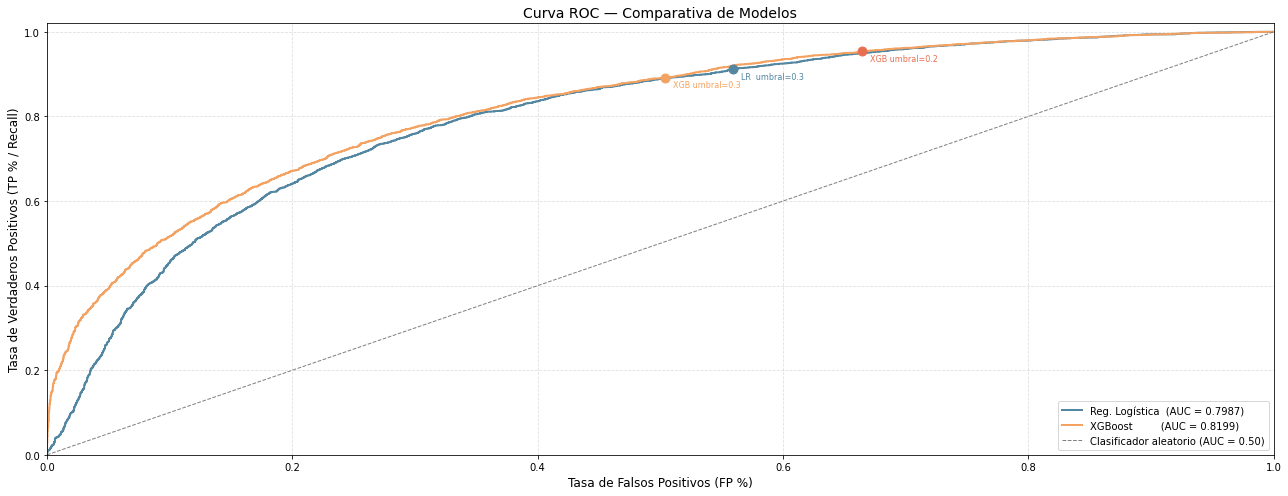

AUC Reg. Logística : 0.7987
AUC XGBoost        : 0.8199


In [46]:
from sklearn.metrics import roc_curve, auc

# Calculo de curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob) # Datos de la logistica
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb) # Datos del xgboost.

auc_lr  = auc(fpr_lr, tpr_lr)
auc_xgb = auc(fpr_xgb, tpr_xgb)

fig, ax = plt.subplots(figsize=(18, 7)) # Grafico

ax.plot(fpr_lr,  tpr_lr,  color='#5286A1', lw=2, label=f'Reg. Logística  (AUC = {auc_lr:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#F4A261', lw=2, label=f'XGBoost         (AUC = {auc_xgb:.4f})')

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio (AUC = 0.50)')

for fpr_arr, tpr_arr, prob_arr, threshold, color, label in [
    (fpr_lr,  tpr_lr,  y_prob,     0.3, '#5286A1', 'LR  umbral=0.3'),
    (fpr_xgb, tpr_xgb, y_prob_xgb, 0.3, '#F4A261', 'XGB umbral=0.3'),
    (fpr_xgb, tpr_xgb, y_prob_xgb, 0.2, '#E76F51', 'XGB umbral=0.2'), # Marca de umbrales utilizados
]:
    # Encontrar el punto más cercano al umbral en la curva
    from sklearn.metrics import roc_curve as _rc
    fprs, tprs, thresholds = _rc(y_test, prob_arr)
    idx = (abs(thresholds - threshold)).argmin()
    ax.scatter(fprs[idx], tprs[idx], color=color, s=80, zorder=5)
    ax.annotate(label, (fprs[idx], tprs[idx]),
                textcoords="offset points", xytext=(8, -10),
                fontsize=8, color=color)

ax.set_xlabel('Tasa de Falsos Positivos (FP %)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TP % / Recall)', fontsize=12)
ax.set_title('Curva ROC — Comparativa de Modelos', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"AUC Reg. Logística : {auc_lr:.4f}")
print(f"AUC XGBoost        : {auc_xgb:.4f}")

La curva ROC es independiente del umbral, evalúa el modelo en todos los umbrales posibles. El AUC resume en un número qué tan bien separa el modelo las clases. Un AUC de 0.82 es bueno.

0.50 → el modelo no distingue clases (azar).  
0.60–0.70 → débil.  
0.70–0.80 → aceptable.  
0.80–0.90 → bueno.  
0.90+ → excelente aunque puede haber overfitting o leakage.

## Matriz de impacto economico (Proyecciones)

Seleccionamos el modelo basándonos en el Costo Total de Error y no solo en métricas estándar. En Argentina, el impacto de un fraude (pérdida de capital + multas) es 8 veces más costoso que la gestión de un bloqueo erróneo.

Costo de un Fraude Escapado ($C_{FN}$): $120.000 (Incluye el monto perdido, la gestión del reclamo y posibles multas bancarias).  

Costo de un Bloqueo Erróneo ($C_{FP}$): $15.000 (Incluye el costo de atención al cliente para desbloquear y la pérdida estimada de margen por una venta que quizás no se concrete). 

Costo de Operación Normal: $0 (No hay pérdida extra).

In [47]:
data = {
    'Modelo': ['Reg. Logística', 'XGBoost (0.3)', 'XGBoost (0.2)'],
    'Fraudes Escapados ($120k c/u)': ['410 × $120k = $49.2M', '505 × $120k = $60.6M', '216 × $120k = $25.9M'],
    'Bloqueos Erróneos ($15k c/u)': ['2.808 × $15k = $42.1M', '2.529 × $15k = $37.9M', '3.336 × $15k = $50.0M'],
    'COSTO TOTAL OPERATIVO': ['$91.300.000', '$98.500.000', '$75.900.000']
}

df2 = pd.DataFrame(data)
df2.style.hide(axis='index')

Modelo,Fraudes Escapados ($120k c/u),Bloqueos Erróneos ($15k c/u),COSTO TOTAL OPERATIVO
Reg. Logística,410 × $120k = $49.2M,2.808 × $15k = $42.1M,$91.300.000
XGBoost (0.3),505 × $120k = $60.6M,2.529 × $15k = $37.9M,$98.500.000
XGBoost (0.2),216 × $120k = $25.9M,3.336 × $15k = $50.0M,$75.900.000


Dado que un fraude no detectado cuesta 8 veces más que un bloqueo erróneo, la estrategia óptima es priorizar la captura de fraudes asumiendo más falsos positivos. Entonces la recomendación es usar XGBoost con threshold 0.2 ya que entrega el menor costo operativo: $75.9 millones, superando ampliamente a las alternativas.

## Explicabilidad del modelo [XGBoost (Umbral 0.2)]

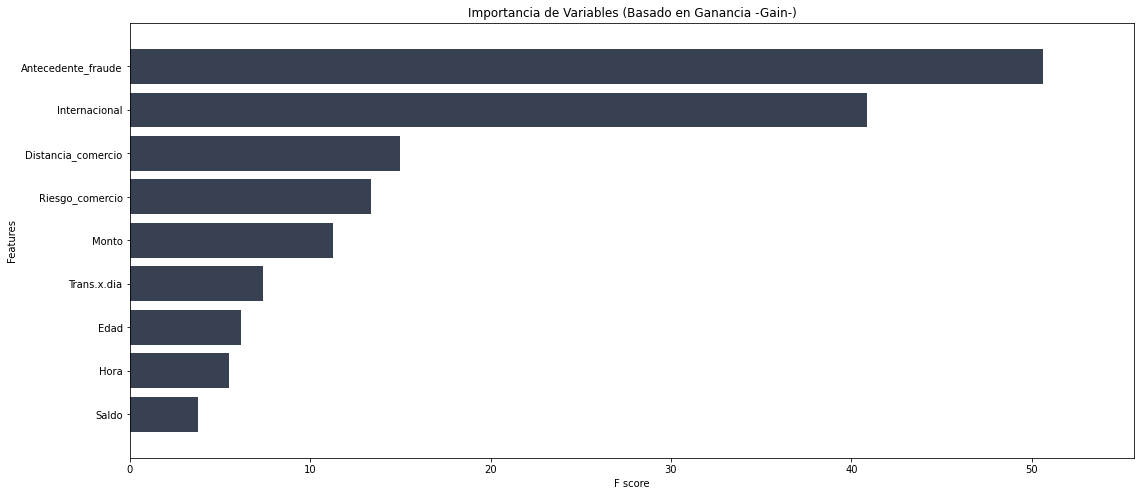

In [48]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Graficar las 10 variables más importantes
fig, ax = plt.subplots(figsize=(18, 8))
plot_importance(xgb_model, max_num_features=10, importance_type='gain',height=0.8, grid=False, ax=ax, show_values=False, color='#374151')
plt.title('Importancia de Variables (Basado en Ganancia -Gain-)')
plt.show()

1- Antecedente_fraude: Es la variable con mayor peso, la que más ayuda al modelo a separar las transacciones legítimas de las fraudulentas con mayor seguridad. El modelo detecta que el fraude es recurrente, si un cliente o una cuenta ya tuvo un evento previo, la probabilidad de reincidencia es el factor determinante. Esto justifica ser estricto con usuarios que ya fallaron validaciones de seguridad. Tambien esta la posibilidad de mejorar aún más el modelo enriqueciendo la base de datos con listas negras actualizadas en tiempo real.

2- Internacional y Distancia_comercio: Las transacciones fuera de Argentina son un foco rojo natural debido a la dificultad de validación y las normativas de cambio. Y por la variable Distancia_comercio se detectan comportamientos imposibles (por ejemplo una compra en Córdoba y otra en CABA con 10 minutos de diferencia).

3- Riesgo_comercio y Monto: Son el perfil del comercio y el monto de operación. El modelo aprendió que ciertos rubros (por ejemplo electrónica, joyería o carga de billeteras virtuales) son más propensos a ataques. Con respecto al Monto el modelo vigila de cerca las transacciones que más dinero le harían perder a la empresa.

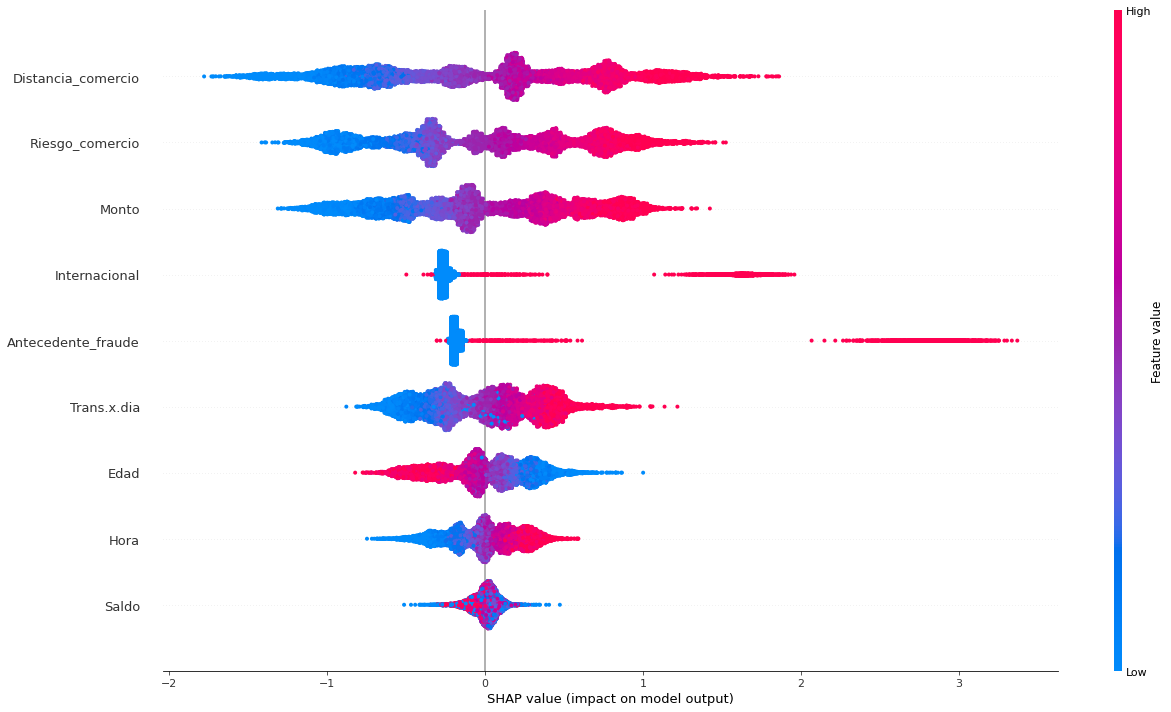

In [49]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_size=(18, 10)) 

Lo que está a la derecha del 0 aumenta el riesgo de fraude, lo que está a la izquierda lo disminuye. En rojo valores altos, en azul valores mas bajos.

Distancia_comercio (El factor más influyente): Vemos que los puntos rojos (valores altos de distancia) están muy a la derecha. Cuanto más lejos está el comercio de la ubicación habitual del cliente, el riesgo de fraude se dispara.

Variables Binarias (como Internacional o Antecedente_fraude): Solo tienen dos valores posibles: Sí (Rojo) o No (Azul). No hay puntos medios por eso se ven como líneas finas y separadas.

Edad: Aquí los puntos azules están a la derecha y los rojos a la izquierda. Los usuarios más jóvenes (valores bajos/azul) parecen tener un riesgo mayor en este set de datos mientras que los de más edad (valores altos/rojo) tienden a disminuir la probabilidad de fraude.

### Análisis de Errores (Falsos Negativos)

En el XGBoost se obtuvo 216 fraudes que no detectó, se analizaran para ver que tienen en comun.

In [50]:
df_analisis = X_test.copy() # Creo un nuevo dataframe copiando los datos de X_test.
df_analisis['real'] = y_test # Agrego la columna "real" al dataframe creado. Esa columna contiene las clases reales que se consiguieron.
df_analisis['pred'] = y_pred_xgb_020 # Agrega la otra columna con las predicciones realizadas por el modelo para poder compararlas con la otra columna.

# Ahora filtro los Falsos Negativos, filtrando lo que en el real da 1 con el conector "Y" comparado con la prediccion cuando es 0.
falsos_negativos = df_analisis[(df_analisis['real'] == 1) & (df_analisis['pred'] == 0)]

print(f"Total de fraudes omitidos: {len(falsos_negativos)}")

Total de fraudes omitidos: 216


In [51]:
falsos_negativos # Tabla de falsos negativos.

,Edad,Monto,Saldo,Trans.x.dia,Internacional,Hora,Antecedente_fraude,Distancia_comercio,Riesgo_comercio,real,pred
10139,69.0,5992.02,41394.38,47.0,0.0,15.0,0.0,800.8,4.3,1,0
28974,38.0,6844.69,2686.11,33.0,0.0,15.0,0.0,2037.0,2.1,1,0
8830,22.0,3541.47,20840.20,31.0,0.0,3.0,0.0,2039.1,2.1,1,0
7744,40.0,368.50,49924.28,0.0,0.0,1.0,0.0,1234.8,7.6,1,0
12668,54.0,4837.07,16473.95,41.0,0.0,5.0,0.0,806.7,5.5,1,0
...,...,...,...,...,...,...,...,...,...,...,...
23673,66.0,6736.50,45326.47,36.0,0.0,1.0,0.0,117.6,7.3,1,0
8363,26.0,5181.87,35464.00,13.0,0.0,19.0,0.0,283.1,1.8,1,0
25604,49.0,737.98,21166.67,32.0,0.0,9.0,0.0,3555.0,4.3,1,0
17399,70.0,5114.69,43412.04,7.0,0.0,18.0,0.0,1694.5,4.9,1,0


In [52]:
# Marcamos cuáles detectamos y cuáles no dentro de los fraudes reales
fraudes_reales = df_analisis[df_analisis['real'] == 1].copy()
fraudes_reales['detectado'] = fraudes_reales['pred'] == 1

# Divide los datos en 2 grupos Fraudes detectados y fraudes omitidos. Muestra el promedio de cada variable para cada grupo.
comparativa = fraudes_reales.groupby('detectado')[['Edad', 'Monto',	'Saldo', 'Trans.x.dia',	'Internacional', 'Hora', 'Antecedente_fraude', 'Distancia_comercio', 'Riesgo_comercio']].mean()
comparativa

,Edad,Monto,Saldo,Trans.x.dia,Internacional,Hora,Antecedente_fraude,Distancia_comercio,Riesgo_comercio
detectado,,,,,,,,,
False,48.478928,5174.386250,25579.000926,19.342593,0.046296,10.222222,0.055556,1636.655556,4.228704
True,44.034104,8601.300288,24747.931370,26.503594,0.268643,11.941824,0.196541,2936.089465,6.170463


Los fraudes omitidos presentan patrones más cercanos al comportamiento habitual de los usuarios: montos más bajos, operaciones locales, menor actividad, menor riesgo aparente.

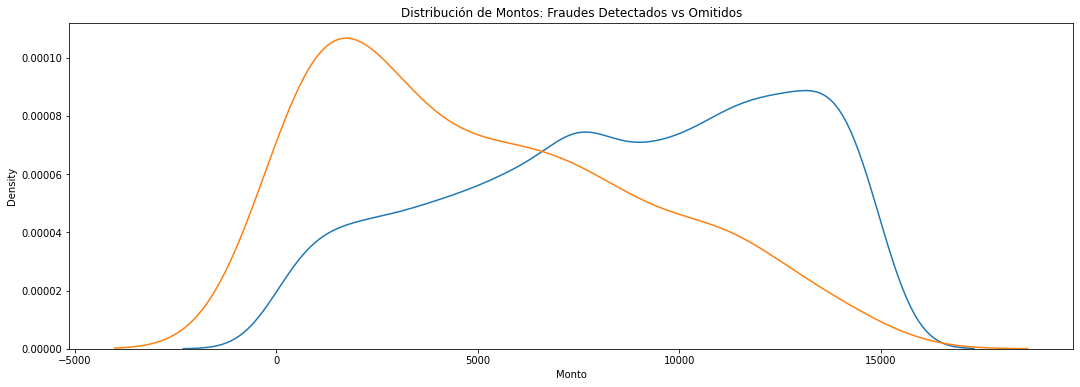

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))
sns.kdeplot(fraudes_reales[fraudes_reales['detectado'] == True]['Monto'], label='Detectados')
sns.kdeplot(fraudes_reales[fraudes_reales['detectado'] == False]['Monto'], label='Omitidos')
plt.title('Distribución de Montos: Fraudes Detectados vs Omitidos')
plt.show()

Los fraudes omitidos (curva naranja los representa) tienden a ocurrir más en montos pequeños. Los fraudes detectados (curva azul) aparecen con mayor frecuencia en montos altos. Tambien se observa que entre aproximadamente $6.000 y $9.000 hay una zona donde ambas distribuciones se cruzan, en esos valores el modelo probablemente tiene más dificultad para diferenciar fraudes. Los montos pequeños parecen más difíciles de detectar porque se mezclan con comportamiento normal y generan más omisiones.

Modelo seleccionado: XGBoost con umbral 0.2
De los tres escenarios evaluados esta configuración logra el menor costo operativo proyectado (75.9M), capturando 4.452 fraudes reales (Recall: 95.37%) con 3.336 bloqueos erróneos. Frente a la Regresión Logística, representa un ahorro estimado de $15.4M en el período analizado.
Limitación principal: el modelo tiene mayor dificultad con fraudes de montos bajos (zona crítica 6.000–9.000), donde el comportamiento se mezcla con operaciones legítimas. Una mejora concreta sería incorporar variables de velocidad transaccional (frecuencia en ventana de 1 hora) para capturar mejor ese patrón.

In [54]:
resumen = pd.DataFrame({
    'Modelo':               ['Reg. Logística (0.3)', 'XGBoost (0.3)', 'XGBoost (0.2) ✓'],
    'Recall':               ['91.22%', '89.18%', '95.37%'],
    'Fraudes detectados':   [4258, 4163, 4452],
    'Fraudes escapados':    [410, 505, 216],
    'Bloqueos erróneos':    [2808, 2529, 3336],
    'Costo total estimado': ['$91.3M', '$98.5M', '$75.9M']
})

resumen.style.hide(axis='index') \
    .set_properties(**{'text-align': 'center'}) \
    .highlight_min(subset=['Costo total estimado'], color='#d4edda') \
    .highlight_min(subset=['Fraudes escapados'], color='#cce5ff')

Modelo,Recall,Fraudes detectados,Fraudes escapados,Bloqueos erróneos,Costo total estimado
Reg. Logística (0.3),91.22%,4258,410,2808,$91.3M
XGBoost (0.3),89.18%,4163,505,2529,$98.5M
XGBoost (0.2) ✓,95.37%,4452,216,3336,$75.9M


<div style="
    margin-top:40px;
    padding:16px;
    border-radius:12px;
    background:linear-gradient(90deg,#0B1220,#111827);
    border-left:4px solid #F59E0B;
    color:#E5E7EB;
    font-size:13px;
    line-height:1.6;
">
<div style="font-weight:600; font-size:14px;">
Néstor Díaz
</div>

<div style="color:#94A3B8;">
Contador Público · Data Analyst · Machine Learning
</div>

<div style="margin-top:8px; color:#F59E0B;">
Proyecto: Detección de Fraude con ML: Del Modelo a la Decisión de Negocio
</div>
</div>